# 2.4 — Stack-and-roll versus strip hedges

> *"MG's hedge was sound. Its funding was not."* — the one-line summary of the 1994 Culp–Miller vs.
> Mello–Parsons debate about the biggest hedging loss of its era

## The problem

Chapter 2.3 showed that hedging a back-month exposure with the front month needs a ratio. But even with
the right ratio, a front-month hedge has a shelf life of one month: the contract expires and must be
**rolled** into the next one. A Dec-27 exposure hedged today in Oct-26 will be rolled about fourteen
times. Each roll:

* crosses the M1/M2 spread (a transaction cost — small),
* *realises* the curve shape (a P&L — potentially large, and with a sign),
* changes the correlation between hedge and exposure (a model risk).

The alternative is a **strip hedge**: sell the actual Dec-27 (or a Win-27 strip that contains it) and
never roll. Precise but illiquid and expensive to execute (Chapter 1.3).

This chapter simulates both, decomposes the P&L, and tells the Metallgesellschaft story — because
everything that can go wrong with stack-and-roll went wrong there in a single year.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_curve_history, month_bucket, liquidity_for
from gashedge.hedging import stack_and_roll, min_variance_hedge_ratio, execution_cost, pnl_stats
from gashedge.plotting import plot_series
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch2.4")
log.info("Environment ready")

2026-09-13 16:47:04.546 | INFO    | ch2.4 | Environment ready


## 1. Roll yield: the sign of the curve becomes your P&L

You are **short** the front month as a hedge. At the roll you buy back M1 at $F_1$ and sell M2 at $F_2$.
Nothing is gained or lost *at that instant* — but over the following month the contract you now hold
short (the old M2) slides toward the front of the curve. If nothing else changes, its price converges
toward where M1 was. In **backwardation** ($F_1 > F_2$) the short position drifts *against* you by
$F_1 - F_2$ per roll; in **contango** ($F_1 < F_2$) it drifts *for* you.

$$
\text{roll P\&L per unit (short hedge)} \;\approx\; -(F_1 - F_2)\quad\text{per roll}
\tag{2.7}
$$

A long exposure hedged with rolled shorts therefore **loses money in backwardation and earns it in
contango** — with the *opposite* signs for a short exposure hedged with rolled longs. Over fourteen rolls
this is not noise; it is a term in the expected P&L, i.e. exactly the $\mu_F$ of equation (2.4) that we
happily set to zero for a single-month hedge.

In [2]:
hist = simulate_curve_history(n_days=750, n_tenors=24)
Q = 100_000                                       # MWh of a long M12 exposure
d = hist.diff().dropna()
h_star = min_variance_hedge_ratio(d.M12, d.M1)
runs = {
    "stack M1, ratio 1:1": stack_and_roll(hist, exposure_tenor=12, exposure_mwh=Q, roll_every=21, ratio=1.0),
    f"stack M1, ratio h*={h_star:.2f}": stack_and_roll(hist, exposure_tenor=12, exposure_mwh=Q, roll_every=21, ratio=h_star),
    "strip hedge (M12 outright)": stack_and_roll(hist, exposure_tenor=12, exposure_mwh=Q, roll_every=10**9, hedge_col="M12", ratio=1.0),
}
summary = pd.DataFrame({k: {"daily std": v.net_pnl.std(), "cum roll P&L": v.roll_pnl.sum(),
                            "cum net P&L": v.net_pnl.sum(), "worst day": v.net_pnl.min(),
                            "max cum drawdown": (v.cum_net - v.cum_net.cummax()).min()} for k, v in runs.items()}).T
summary.round(0)

2026-09-13 16:47:04.554 | INFO    | gashedge.market_data | Simulated constant-maturity curve history: 750 days x 24 tenors


2026-09-13 16:47:04.557 | INFO    | gashedge.hedging | Stack-and-roll M12 with M1: net std 249289 EUR/day, cum roll P&L -27043900 EUR


2026-09-13 16:47:04.558 | INFO    | gashedge.hedging | Stack-and-roll M12 with M1: net std 93020 EUR/day, cum roll P&L -9756715 EUR


2026-09-13 16:47:04.559 | INFO    | gashedge.hedging | Stack-and-roll M12 with M12: net std 0 EUR/day, cum roll P&L 0 EUR


,daily std,cum roll P&L,cum net P&L,worst day,max cum drawdown
"stack M1, ratio 1:1",249289.0,-27043900.0,-29848800.0,-2734200.0,-30123500.0
"stack M1, ratio h*=0.36",93020.0,-9756715.0,-9436883.0,-974738.0,-9550983.0
strip hedge (M12 outright),0.0,0.0,0.0,0.0,0.0


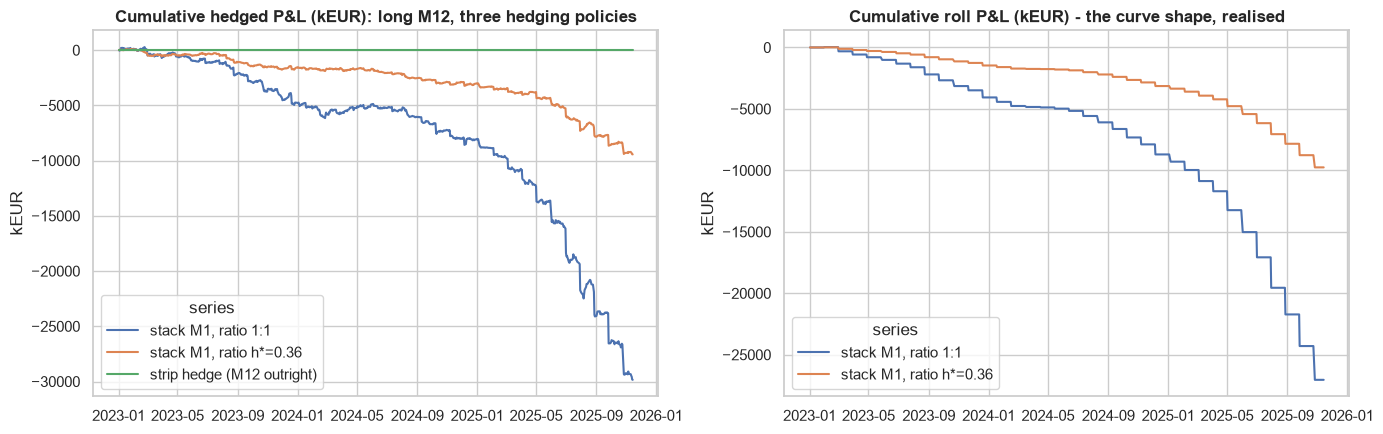

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
cum = pd.DataFrame({k: v.cum_net for k, v in runs.items()})
plot_series(cum / 1e3, title="Cumulative hedged P&L (kEUR): long M12, three hedging policies", ylabel="kEUR", ax=axes[0])
roll = pd.DataFrame({k: v.roll_pnl.cumsum() for k, v in list(runs.items())[:2]})
plot_series(roll / 1e3, title="Cumulative roll P&L (kEUR) - the curve shape, realised", ylabel="kEUR", ax=axes[1])
plt.tight_layout()

Three lessons in one picture:

* The **1:1 stack** is by far the noisiest — the tenor mismatch of Chapter 2.3 all over again.
* The **ratio stack** is much calmer but carries a *drift*: the accumulated roll P&L. Its sign depends on
  whether the front of the curve was in backwardation or contango on the roll dates. (The simulation has a
  gentle backwardation and *no* seasonality; on a real curve the Sep→Oct and Mar→Apr rolls cross the
  seasonal step and are far larger — in both directions.)
* The **strip hedge** is flat — in a constant-maturity simulation it is *perfect*, because we hedged the
  exposure with itself. In reality it costs the M12 bid–ask and impact and may not be available in size.

## 2. Putting a price on each policy

Let us total three costs over one year on the 100,000 MWh position: execution cost (Chapter 1.3),
realised roll P&L, and residual risk expressed as a **risk charge** $\lambda \sigma^2$ per day (the
variance penalty of equation (2.3)), with a modest $\lambda$.

In [4]:
lam = 2e-7                    # EUR^-1, risk-aversion for the variance penalty
days = 250
lot_H = 730
m1_liq, m12_liq = liquidity_for(month_bucket(1)), liquidity_for(month_bucket(12))
lots = Q / lot_H

def yearly_cost(run, n_rolls, ratio, liq, initial_liq=None):
    initial_liq = initial_liq or liq
    exec_initial = execution_cost(ratio * lots, initial_liq["bid_ask"], lot_H, initial_liq["depth_lots"])
    exec_rolls = n_rolls * 2 * execution_cost(ratio * lots, liq["bid_ask"], lot_H, liq["depth_lots"]) * 0.5  # spread trades ~ half the outright cost
    risk_charge = lam * run.net_pnl.var() * days
    roll_pnl = run.roll_pnl.iloc[:days].sum()
    return {"execution (initial)": exec_initial, "execution (rolls)": exec_rolls, "roll P&L": roll_pnl,
            "risk charge lambda*var*days": risk_charge}

costs = pd.DataFrame({
    "stack M1 1:1": yearly_cost(runs["stack M1, ratio 1:1"], 12, 1.0, m1_liq),
    f"stack M1 h*": yearly_cost(runs[f"stack M1, ratio h*={h_star:.2f}"], 12, h_star, m1_liq),
    "strip M12": yearly_cost(runs["strip hedge (M12 outright)"], 0, 1.0, m12_liq),
}).T
costs["total (negative = cost)"] = -costs["execution (initial)"] - costs["execution (rolls)"] + costs["roll P&L"] - costs["risk charge lambda*var*days"]
log.info("One-year all-in comparison (EUR): %s", costs["total (negative = cost)"].round(0).to_dict())
costs.round(0)

2026-09-13 16:47:04.812 | INFO    | ch2.4 | One-year all-in comparison (EUR): {'stack M1 1:1': -6613578.0, 'stack M1 h*': -1695896.0, 'strip M12': -18703.0}


,execution (initial),execution (rolls),roll P&L,risk charge lambda*var*days,total (negative = cost)
stack M1 1:1,1425.0,17103.0,-3487800.0,3107249.0,-6613578.0
stack M1 h*,381.0,4571.0,-1258305.0,432640.0,-1695896.0
strip M12,18703.0,0.0,0.0,0.0,-18703.0


The exact numbers depend on the seed and on $\lambda$ — change them and watch the ranking. What does
*not* change: the 1:1 stack is dominated, and the choice between the ratio stack and the strip is a
trade-off between **execution cost now** (strip) and **roll P&L + residual variance later** (stack).
Desks resolve it with a hybrid: **stack now, migrate later** — put the delta on in the front immediately,
then work the M12 (or a season) over days or weeks at low participation, unwinding the front as the
strip fills. You pay the strip's cost anyway, but you never sit unhedged, and you never roll fourteen
times.

## 3. Metallgesellschaft Refining & Marketing, 1993

The canonical case, worth knowing in detail because every element recurs in gas:

* **The exposure.** MGRM sold ~160 million barrels of heating oil and gasoline to US customers on
  **fixed-price contracts up to ten years long**. It was short oil, far out along the curve.
* **The hedge.** Long-dated futures did not exist in size, so MGRM went **long a stack of front-month
  NYMEX futures and OTC swaps, roughly barrel-for-barrel**, intending to roll monthly for years.
  Note: 1:1 in *barrels*, not in *risk* — the mismatch of Chapter 2.3.
* **What happened.** Oil fell from about \$19 to about \$15 through 1993. The long futures lost and paid
  **variation margin in cash every day** — over \$1 bn. The fixed-price customer contracts *gained*
  equivalently, but those gains were unrealised, spread over a decade of deliveries. Simultaneously the
  curve flipped from backwardation into **contango**, so each monthly roll of the long stack *cost*
  money (the mirror image of equation 2.7).
* **The end.** With margin calls exceeding credit lines, the parent board liquidated the hedge near the
  bottom in December 1993, crystallising a loss of about \$1.3 bn — and then was left with the *unhedged*
  customer contracts as prices recovered.
* **The debate.** Culp and Miller (1994) argued the hedge was economically sound and would have paid off
  if funded; Mello and Parsons (1995) argued that 1:1 stacking of a long-dated exposure was over-hedged
  by a factor of two or more (the Samuelson effect: the front moves more than the back) and that the
  funding risk was intrinsic to the design, not bad luck.

For our purposes both sides are right, and together they give the checklist:

1. **Ratio, not barrels** (Chapter 3.2) — the back moves less than the front.
2. **Roll yield is a P&L term with a sign** — model it, do not assume $\mu_F = 0$ for a multi-year roll.
3. **Funding is part of the hedge** — simulate margin under stress (Chapter 2.2), size liquidity lines
   before the position, not after.
4. **Governance** — a board that does not understand the hedge will unwind it at the worst moment.

2026-09-13 16:47:04.835 | INFO    | ch2.4 | Peak cumulative hedge cash outflow: 11.52 mm EUR against a net P&L range of 9.55 mm EUR


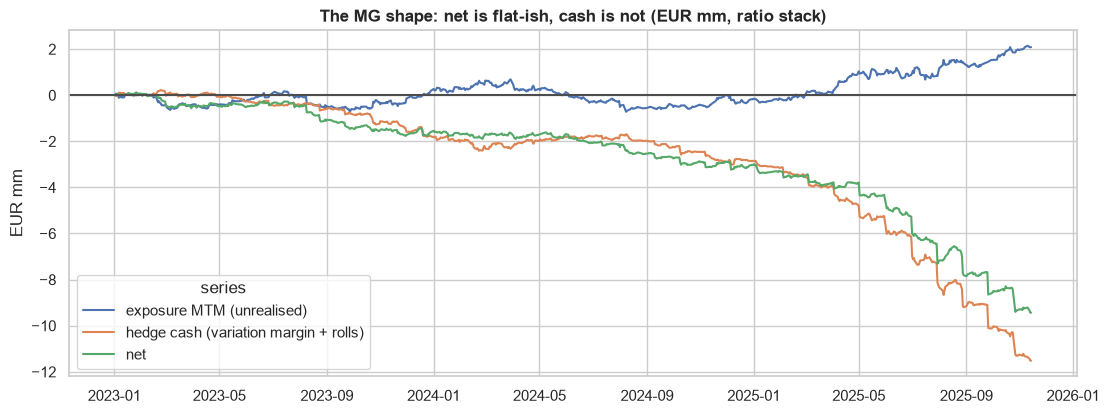

In [5]:
run = runs[f"stack M1, ratio h*={h_star:.2f}"]
cashflows = pd.DataFrame({"exposure MTM (unrealised)": run.cum_exposure, "hedge cash (variation margin + rolls)": run.cum_hedge_cash, "net": run.cum_net})
fig, ax = plt.subplots(figsize=(13, 4.5))
plot_series(cashflows / 1e6, title="The MG shape: net is flat-ish, cash is not (EUR mm, ratio stack)", ylabel="EUR mm", ax=ax)
ax.axhline(0, color="0.3")
log.info("Peak cumulative hedge cash outflow: %.2f mm EUR against a net P&L range of %.2f mm EUR",
         -run.cum_hedge_cash.min() / 1e6, (run.cum_net.max() - run.cum_net.min()) / 1e6)

## 4. Where this leaves us

Stack-and-roll is the workhorse for exposures beyond the liquid front, provided it is sized by ratio,
its roll yield is modelled, and its margin path is funded. Strips are the precise alternative when
liquidity allows; the hybrid "stack and migrate" is what most desks actually run.

**Pitfall that leads to the next chapter:** all of this assumed we hedge *once* and maintain. But the
exposure itself changes every minute as the market-making books trade. Re-hedging every fill maximises
cost; re-hedging once a day maximises intraday risk. The optimal *frequency* — and its cousin, the
hedging *band* — is Chapter 2.5.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** You are short 10,000 MWh of front-month futures as a hedge and roll monthly. The M1/M2 spread on the roll date is $F_1 - F_2 = +0.80$ EUR/MWh (backwardation). What is the approximate roll P&L of this roll, and what would it be if the curve were in contango at $-0.80$? What is the annual drift if this repeats twelve times?

<details><summary><i>Answer 1</i></summary>

By (2.7), rolling a short in backwardation costs $10{,}000 \times 0.80 = \mathbf{-€8{,}000}$ per roll; in contango at $-0.80$ it earns $\mathbf{+€8{,}000}$. Twelve identical rolls: $\mathbf{-€96{,}000}$ per year in backwardation (or $+€96{,}000$ in contango). On a €35 price that is ~2.7 % of notional per year — comparable to the *entire* annual spread income of a small market-making book, and it must appear as $\mu_F$ in the hedge decision, not be ignored.

</details>

**Q2.** Explain, using the Samuelson effect, why Mello and Parsons argued MGRM's barrel-for-barrel stack was *over*-hedged, and estimate the factor if front-month vol is 35 % and the average vol of the 1–10 year exposure is 15 % with correlation 0.8.

<details><summary><i>Answer 2</i></summary>

The exposure was far along the curve and moved much less per day than the front month; a 1:1 stack in barrels therefore had far more *dollar volatility* than the thing it hedged. Minimum-variance ratio $h^* = \rho\,\sigma_S/\sigma_F = 0.8 \times 15/35 = \mathbf{0.34}$. MGRM's ratio of ~1.0 was thus **~3× too large**: two-thirds of the stack was an outright long oil position, which is precisely what lost money when oil fell. (Culp–Miller's reply — that a 1:1 hedge is right for a *one-period* commitment to deliver later at a fixed price — is correct in the absence of the Samuelson effect and irrelevant in its presence.)

</details>

**Q3.** A desk proposes to hedge a Win-27 exposure (Oct-27 to Mar-28) by stacking in the front month and rolling for a year. List the roll dates' *seasonal* problem and explain why 'stack and migrate' into the Win-27 strip is better even though the strip is less liquid.

<details><summary><i>Answer 3</i></summary>

Rolling monthly through 2026-27 means crossing the Sep→Oct roll (summer to winter: large *positive* $F_2 - F_1$, contango-like, favourable to a short roller) and the Mar→Apr roll (winter to summer: large *negative*, backwardation-like, costly), plus many small ones. The net seasonal roll P&L may cancel but its *path* is lumpy and its sign depends on the seasonal spread level at each roll — a spread exposure the desk never chose. The Win-27 strip is the *exact* exposure: zero tenor basis, zero roll, and Chapter 1.3 tells us the nearest seasons are among the most liquid strips anyway. Stack-and-migrate gets the level risk off in minutes and removes the roll exposure within days.

</details>

**Q4.** MGRM's parent unwound the hedge at the bottom. Suppose instead it had had unlimited liquidity and held the position: sketch what would have happened to (a) the futures P&L, (b) the customer-contract P&L, and (c) the roll P&L over 1994–95 as oil recovered and the curve returned to backwardation. What is the lesson for how you *present* a hedging programme internally?

<details><summary><i>Answer 4</i></summary>

(a) The long futures would have recovered as oil rose from \$15 back toward \$18–20, returning much of the margin paid out. (b) The fixed-price customer contracts would have lost equivalent value — the two legs offset, as designed. (c) With the curve back in backwardation, monthly rolls of a long stack would have *earned* roll yield, partially recouping the contango losses of 1993. Net: a large fraction of the \$1.3 bn was a *timing* loss crystallised by liquidation, not an economic loss of the hedge. Lesson: present a hedging programme with its **cash-flow path under stress** and pre-agreed **liquidity lines and governance triggers**, so that the decision to hold or unwind is taken before the crisis by people who understand the offsetting leg — not during it by people who see only the margin calls.

</details>


---
◀ [Previous](03_one_to_one_and_mismatches.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](05_hedge_timing_and_cost.ipynb)